In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [2]:
import os

print("Folders inside /kaggle/input:")
print(os.listdir("/kaggle/input"))

for folder in os.listdir("/kaggle/input"):
    folder_path = os.path.join("/kaggle/input", folder)
    print(f"\nInside: {folder_path}")
    try:
        items = os.listdir(folder_path)
        print(items[:20])
    except Exception as e:
        print("Error:", e)

Folders inside /kaggle/input:
['datasets']

Inside: /kaggle/input/datasets
['organizations', 'victorling', 'amelemad202201991']


In [3]:
import os
import csv
import math
import random
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SAMPLE_RATE = 16000
N_MELS = 80
BATCH_SIZE = 8
BEAM_WIDTH = 10

Device: cuda


In [4]:
BEST_MODEL_PATH = "/kaggle/input/datasets/amelemad202201991/best-model/best_speech_model.pth"

LIBRISPEECH_PATH = "/kaggle/input/datasets/victorling/librispeech-clean/LibriSpeech/train-clean-100"
COMMONVOICE_PATH = "/kaggle/input/datasets/organizations/mozillaorg/common-voice"
COMMONVOICE_CSV = os.path.join(COMMONVOICE_PATH, "cv-valid-test.csv")
COMMONVOICE_AUDIO_FOLDER = os.path.join(COMMONVOICE_PATH, "cv-valid-test")

In [5]:
import os

print(os.listdir(COMMONVOICE_PATH))

['cv-valid-test', 'cv-invalid', 'cv-other-test', 'cv-other-train.csv', 'cv-invalid.csv', 'cv-valid-dev.csv', 'README.txt', 'cv-valid-train.csv', 'LICENSE.txt', 'cv-valid-test.csv', 'cv-valid-dev', 'cv-other-dev.csv', 'cv-other-dev', 'cv-valid-train', 'cv-other-train', 'cv-other-test.csv']


In [6]:
CHARS = list("abcdefghijklmnopqrstuvwxyz '")
char_to_idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx_to_char = {i + 1: c for i, c in enumerate(CHARS)}

BLANK_LABEL = 0
VOCAB_SIZE = len(CHARS) + 1

def text_to_indices(text):
    text = text.lower()
    return [char_to_idx[c] for c in text if c in char_to_idx]

def indices_to_text(indices):
    return "".join(idx_to_char[i] for i in indices if i in idx_to_char)

def levenshtein(a, b):
    n = len(a)
    m = len(b)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]

def cer_score(reference, prediction):
    ref = list(reference)
    pred = list(prediction)

    if len(ref) == 0:
        return 0.0 if len(pred) == 0 else 1.0

    return levenshtein(ref, pred) / len(ref)

def wer_score(reference, prediction):
    ref_words = reference.split()
    pred_words = prediction.split()

    if len(ref_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein(ref_words, pred_words) / len(ref_words)

In [7]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=400,
    win_length=400,
    hop_length=160
)

db_transform = torchaudio.transforms.AmplitudeToDB()

def normalize_spec(spec):
    mean = spec.mean()
    std = spec.std()
    return (spec - mean) / (std + 1e-5)

def collate_fn(batch):
    specs = []
    input_lengths = []
    labels = []
    label_lengths = []
    transcripts = []

    for waveform, transcript, label in batch:
        waveform = waveform.squeeze(0)

        spec = mel_transform(waveform)
        spec = db_transform(spec)
        spec = normalize_spec(spec)

        input_lengths.append(spec.shape[1])
        specs.append(spec)

        labels.append(label)
        label_lengths.append(len(label))
        transcripts.append(transcript)

    max_time = max(input_lengths)

    padded_specs = []
    for spec in specs:
        pad_amount = max_time - spec.shape[1]
        if pad_amount > 0:
            spec = nn.functional.pad(spec, (0, pad_amount))
        padded_specs.append(spec)

    padded_specs = torch.stack(padded_specs)
    labels = torch.cat(labels)

    input_lengths = torch.tensor(input_lengths, dtype=torch.long)
    label_lengths = torch.tensor(label_lengths, dtype=torch.long)

    return padded_specs, labels, input_lengths, label_lengths, transcripts

In [8]:
class MyLibriSpeechDataset(Dataset):
    def __init__(self, root_folder, max_samples=None):
        self.samples = []

        for speaker_id in os.listdir(root_folder):
            speaker_path = os.path.join(root_folder, speaker_id)
            if not os.path.isdir(speaker_path):
                continue

            for chapter_id in os.listdir(speaker_path):
                chapter_path = os.path.join(speaker_path, chapter_id)
                if not os.path.isdir(chapter_path):
                    continue

                transcript_file = os.path.join(chapter_path, f"{speaker_id}-{chapter_id}.trans.txt")
                if not os.path.exists(transcript_file):
                    continue

                transcript_dict = {}
                with open(transcript_file, "r", encoding="utf-8") as f:
                    for line in f:
                        parts = line.strip().split(" ", 1)
                        if len(parts) == 2:
                            file_id, text = parts
                            transcript_dict[file_id] = text.lower()

                for file_name in os.listdir(chapter_path):
                    if file_name.endswith(".flac"):
                        file_id = file_name.replace(".flac", "")
                        file_path = os.path.join(chapter_path, file_name)

                        if file_id in transcript_dict:
                            self.samples.append((file_path, transcript_dict[file_id]))

                        if max_samples is not None and len(self.samples) >= max_samples:
                            return

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, transcript = self.samples[idx]

        waveform, sr = torchaudio.load(file_path)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        label = torch.tensor(text_to_indices(transcript), dtype=torch.long)
        return waveform, transcript, label

In [9]:
class CommonVoiceDataset(Dataset):
    def __init__(self, csv_file, audio_folder, max_samples=300):
        self.samples = []

        with open(csv_file, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)

            for row in reader:
                if "filename" not in row or "text" not in row:
                    continue

                audio_path = os.path.join(audio_folder, row["filename"])
                sentence = row["text"].lower()

                filtered_sentence = "".join([c for c in sentence if c in char_to_idx])

                if len(filtered_sentence) == 0:
                    continue

                if os.path.exists(audio_path):
                    self.samples.append((audio_path, filtered_sentence))

                if len(self.samples) >= max_samples:
                    break

        print("Loaded Common Voice samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, transcript = self.samples[idx]

        waveform, sr = torchaudio.load(file_path)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

        label = torch.tensor(text_to_indices(transcript), dtype=torch.long)

        return waveform, transcript, label

In [10]:
class SpeechModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d((2, 1))
        )

        self.lstm_input_size = 128 * 10

        self.bilstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=256,
            num_layers=3,
            dropout=0.3,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(512, VOCAB_SIZE)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)

        b, c, f, t = x.size()

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, t, c * f)

        x, _ = self.bilstm(x)
        x = self.dropout(x)
        x = self.fc(x)
        x = x.log_softmax(dim=2)

        return x

In [11]:
def greedy_decode(log_probs, blank=0):
    pred_ids = torch.argmax(log_probs, dim=2)
    results = []

    for seq in pred_ids:
        decoded = []
        previous = blank

        for idx in seq.tolist():
            if idx != blank and idx != previous:
                decoded.append(idx)
            previous = idx

        results.append(indices_to_text(decoded))

    return results

In [12]:
ctc_loss = nn.CTCLoss(blank=BLANK_LABEL, zero_infinity=True)

def evaluate_model(model, dataloader):
    model.eval()

    total_loss = 0
    total_cer = 0
    total_wer = 0
    total_samples = 0

    all_results = []

    with torch.no_grad():
        for specs, labels, input_lengths, label_lengths, transcripts in dataloader:
            specs = specs.to(DEVICE)
            labels = labels.to(DEVICE)
            input_lengths = input_lengths.to(DEVICE)
            label_lengths = label_lengths.to(DEVICE)

            outputs = model(specs)

            output_lengths = torch.full(
                size=(outputs.size(0),),
                fill_value=outputs.size(1),
                dtype=torch.long
            ).to(DEVICE)

            loss = ctc_loss(
                outputs.permute(1, 0, 2),
                labels,
                output_lengths,
                label_lengths
            )

            predictions = greedy_decode(outputs.cpu())

            batch_size = len(transcripts)
            total_loss += loss.item()

            for ref, pred in zip(transcripts, predictions):
                cer = cer_score(ref, pred)
                wer = wer_score(ref, pred)

                total_cer += cer
                total_wer += wer
                total_samples += 1

                all_results.append({
                    "reference": ref,
                    "prediction": pred,
                    "cer": cer,
                    "wer": wer
                })

    avg_loss = total_loss / len(dataloader)
    avg_cer = total_cer / total_samples
    avg_wer = total_wer / total_samples

    return avg_loss, avg_cer, avg_wer, all_results

In [13]:
model = SpeechModel().to(DEVICE)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and "model_state_dict" not in checkpoint:
    model.load_state_dict(checkpoint)

elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [14]:
librispeech_dataset = MyLibriSpeechDataset(LIBRISPEECH_PATH)

print("Total LibriSpeech samples:", len(librispeech_dataset))

# Use small subset for faster testing
test_size = min(300, len(librispeech_dataset))
librispeech_subset, _ = random_split(
    librispeech_dataset,
    [test_size, len(librispeech_dataset) - test_size]
)

librispeech_loader = DataLoader(
    librispeech_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("LibriSpeech test samples:", len(librispeech_subset))

Total LibriSpeech samples: 28539
LibriSpeech test samples: 300


In [15]:
libri_loss, libri_cer, libri_wer, libri_results = evaluate_model(
    model,
    librispeech_loader
)

print("LibriSpeech Results")
print("Loss:", libri_loss)
print("CER:", libri_cer)
print("WER:", libri_wer)

LibriSpeech Results
Loss: 0.18023364873308884
CER: 0.050900054631240456
WER: 0.18370838752048177


In [16]:
model.eval()

sample_waveform, sample_text, _ = librispeech_dataset[0]

spec = mel_transform(sample_waveform.squeeze(0))
spec = db_transform(spec)
spec = normalize_spec(spec)

spec = spec.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = model(spec)
    prediction = greedy_decode(output.cpu())[0]

print("Reference :", sample_text)
print("Prediction:", prediction)

Reference : gwendolen looked toward the window again with an expression which seemed like a gradual awakening to new thoughts the twilight was perceptibly deepening
Prediction: gwendolen looked tward the window again with an expression which seemed like a gradual awakening to knew thoughts the twilight was perceptibly deepening


In [17]:
commonvoice_dataset = CommonVoiceDataset(
    COMMONVOICE_CSV,
    COMMONVOICE_AUDIO_FOLDER,
    max_samples=300
)

print("Total Common Voice samples:", len(commonvoice_dataset))

commonvoice_loader = DataLoader(
    commonvoice_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

Loaded Common Voice samples: 300
Total Common Voice samples: 300


In [18]:
cv_loss, cv_cer, cv_wer, cv_results = evaluate_model(
    model,
    commonvoice_loader
)

print("Common Voice Results")
print("Loss:", cv_loss)
print("CER:", cv_cer)
print("WER:", cv_wer)

Common Voice Results
Loss: 1.202615626548466
CER: 0.2944108727837357
WER: 0.6126879242761595


In [19]:
print("Sample LibriSpeech Predictions:")
for i in range(min(5, len(libri_results))):
    print("=" * 80)
    print("Reference :", libri_results[i]["reference"])
    print("Prediction:", libri_results[i]["prediction"])
    print("CER:", round(libri_results[i]["cer"], 3))
    print("WER:", round(libri_results[i]["wer"], 3))

print("\nSample Common Voice Predictions:")
for i in range(min(5, len(cv_results))):
    print("=" * 80)
    print("Reference :", cv_results[i]["reference"])
    print("Prediction:", cv_results[i]["prediction"])
    print("CER:", round(cv_results[i]["cer"], 3))
    print("WER:", round(cv_results[i]["wer"], 3))

Sample LibriSpeech Predictions:
Reference : lake would never have counted for anything at all suppose she did turn him down in itself that wasn't a thing to break her father's heart what did matter was not whether she threw lake over but what she threw him over for
Prediction: lake would never have counted for anything it all suppose she did turnim down in itself that was n't a thing to break her father's heart what did matter was not whether she threw lake over but what she threw him overfor
CER: 0.023
WER: 0.163
Reference : roman life came into being with a toga'd gesture a line of horace a sudden vision of an emperor's murder
Prediction: roman life came into being with a toged gesture a line of horas a sudden vision of an imperor's murder
CER: 0.048
WER: 0.15
Reference : it advances this idea with persistency and delivers itself of long arguments showing how and why this menace will not be permitted to arise
Prediction: it advances this idea with persistancy and delivers itself of l

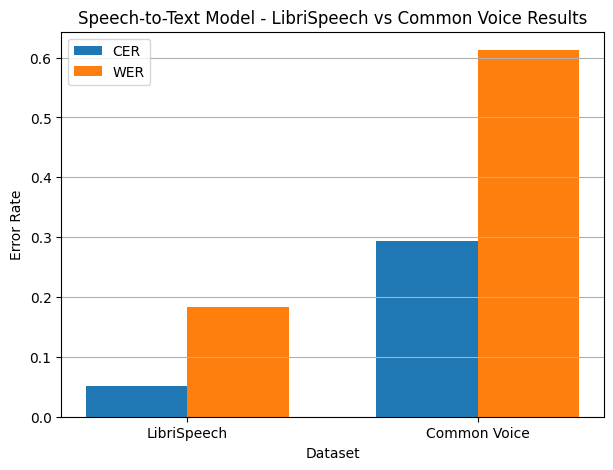

In [20]:
datasets = ["LibriSpeech", "Common Voice"]
cer_values = [libri_cer, cv_cer]
wer_values = [libri_wer, cv_wer]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, cer_values, width, label="CER")
plt.bar(x + width/2, wer_values, width, label="WER")
plt.title("Speech-to-Text Model - LibriSpeech vs Common Voice Results")
plt.xlabel("Dataset")
plt.ylabel("Error Rate")
plt.xticks(x, datasets)
plt.legend()
plt.grid(axis="y")
plt.show()

In [22]:
import pandas as pd

summary_df = pd.DataFrame({
    "Dataset": ["LibriSpeech", "Common Voice"],
    "Loss": [libri_loss, cv_loss],
    "CER": [libri_cer, cv_cer],
    "WER": [libri_wer, cv_wer]
})

summary_df.to_csv("stt_evaluation_summary.csv", index=False)

summary_df

,Dataset,Loss,CER,WER
0,LibriSpeech,0.180234,0.050900,0.183708
1,Common Voice,1.202616,0.294411,0.612688


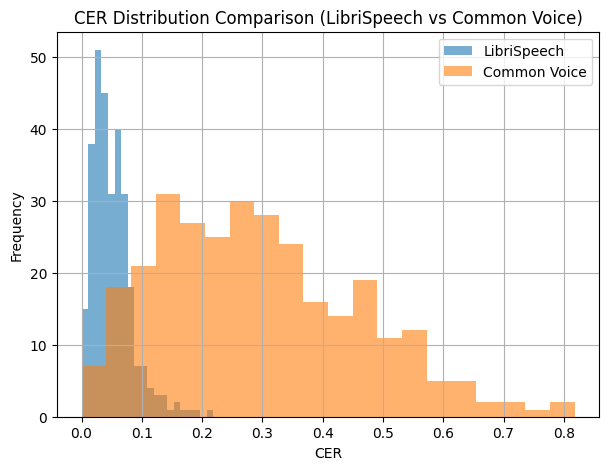

In [26]:
libri_cer_values = [r["cer"] for r in libri_results]
cv_cer_values = [r["cer"] for r in cv_results]

plt.figure(figsize=(7,5))

plt.hist(libri_cer_values, bins=20, alpha=0.6, label="LibriSpeech")
plt.hist(cv_cer_values, bins=20, alpha=0.6, label="Common Voice")

plt.title("CER Distribution Comparison (LibriSpeech vs Common Voice)")
plt.xlabel("CER")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

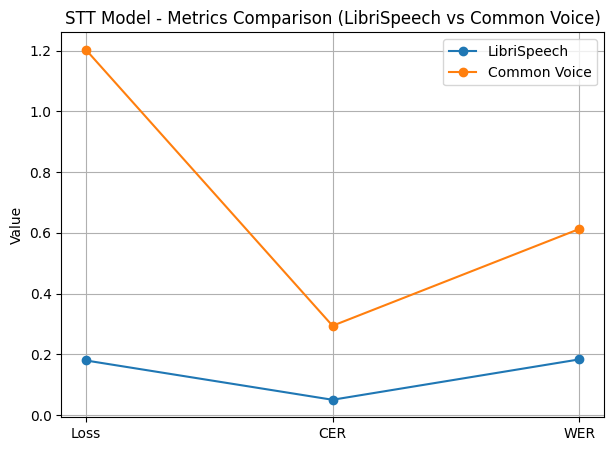

In [27]:
metrics = ["Loss", "CER", "WER"]

libri_values = [libri_loss, libri_cer, libri_wer]
cv_values = [cv_loss, cv_cer, cv_wer]

plt.figure(figsize=(7,5))

plt.plot(metrics, libri_values, marker='o', label="LibriSpeech")
plt.plot(metrics, cv_values, marker='o', label="Common Voice")

plt.title("STT Model - Metrics Comparison (LibriSpeech vs Common Voice)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

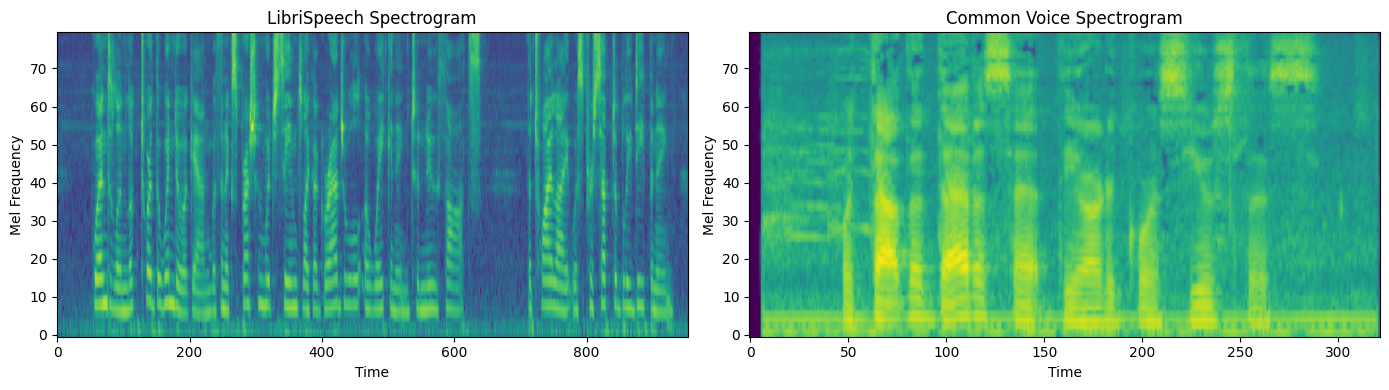

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

# Libri
wave1, text1, _ = librispeech_dataset[0]
spec1 = db_transform(mel_transform(wave1.squeeze(0)))

axes[0].imshow(spec1.numpy(), aspect='auto', origin='lower')
axes[0].set_title("LibriSpeech Spectrogram")

# Common Voice
wave2, text2, _ = commonvoice_dataset[0]
spec2 = db_transform(mel_transform(wave2.squeeze(0)))

axes[1].imshow(spec2.numpy(), aspect='auto', origin='lower')
axes[1].set_title("Common Voice Spectrogram")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

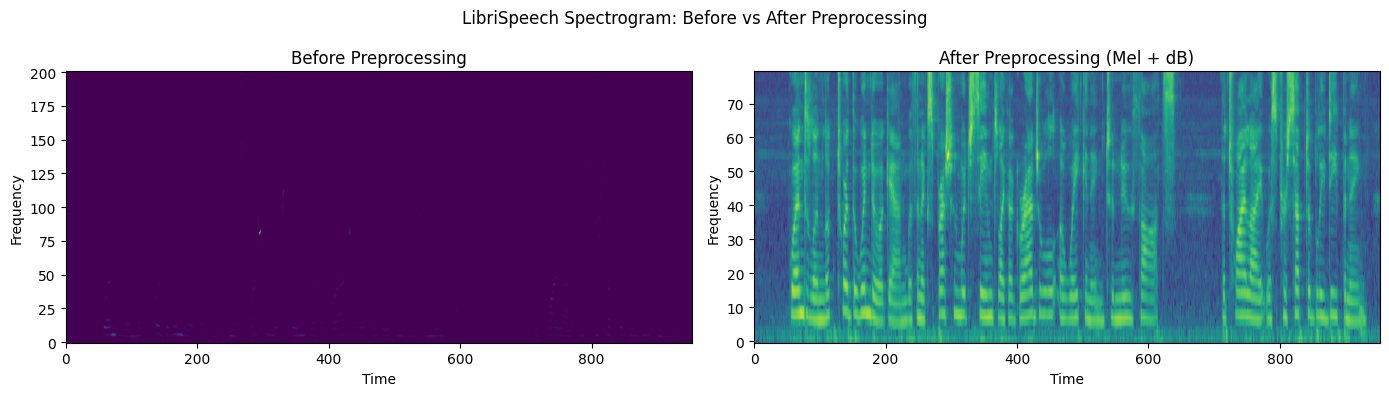

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

waveform, transcript, _ = librispeech_dataset[0]

# BEFORE
raw_spec = torchaudio.transforms.Spectrogram(
    n_fft=400,
    win_length=400,
    hop_length=160
)(waveform)

axes[0].imshow(raw_spec.squeeze().numpy(), aspect='auto', origin='lower')
axes[0].set_title("Before Preprocessing")

# AFTER
mel_spec = db_transform(mel_transform(waveform.squeeze(0)))
axes[1].imshow(mel_spec.numpy(), aspect='auto', origin='lower')
axes[1].set_title("After Preprocessing (Mel + dB)")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")

plt.suptitle("LibriSpeech Spectrogram: Before vs After Preprocessing")
plt.tight_layout()
plt.show()